# CSE428 Assignment 2


In [50]:
NAME = "AHASAN HABIB"
ID = "24141256"
COLLABORATORS_ID = "24141261"

This assignment contains 4 tasks. Complete the notebook with proper codes for the lines with `# TO-BE-COMPLETED` tag, or by *uncommenting* a partially written codes where necessary.

Background: We larned in class that linear spatial filtering is basically a signal correlation opration between an image and a filter kernel. To filter an ```image``` with a ```kernel``` all we need to do is call the ```signal.correlate``` function from the ```scipy``` library.

```
filtered_image = signal.correlate(image, kernel, mode='same', method='auto')
```
Here, ```mode="same"``` takes care of the image padding under the hood; making the filtered image the *same shape* as the input image, while ```mode="valid"``` *shrinks the filtered image*. The ```method='direct'``` implements the correlation from the definition of signal correlation:

> $g(x, y)=\sum_{s,t}{w(s, t)}f(x+s, y+t)$

whereas ```method='fft'``` uses a frequency domain implementation which we will learn next week. The ```method='auto'``` chooses the faster implementation automatically. <br>
(Except for **Task 1**, always use ```method='auto'``` while using the correlation function )




We use the following code stucture to measure the excecution time of some python code:

```
import time

start_time = time.clock()

# some python code

print("Time elapsed: ", time.clock() - start_time, "seconds")
```


## **Task 0: The Imports** <br>
### Import the necessary libraries and define the helper functions. You can use the helper functions from the coding tutorials, or you can even use your own version of helper functions. <br>


In [51]:
# Import libraries
from skimage.io import imread
from skimage import img_as_float
from skimage.color import rgb2gray
from skimage.util import random_noise
import numpy as np
from numpy import pad
from scipy import signal
import matplotlib.pyplot as plt
import time

 # TO-BE-COMPLETED
 # TO-BE-COMPLETED
 # TO-BE-COMPLETED ....


In [52]:
# Define helper functions

def plot_image(img, figsize=(5,5)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.show()
    print("Image shape: ", img.shape)

def plot_kernel(kernel, cmap="Reds"):
    plt.imshow(kernel, interpolation='none', cmap=cmap)
    plt.colorbar()
    plt.show()
    print("Kernel shape: ", kernel.shape)

def gaussian_kernel(width=1, size=10):
    x = np.linspace(-size // 2, size // 2, size)
    gaussian1dkernel = np.exp(-0.5 * (x / width)**2)
    gaussian1dkernel /= np.sum(gaussian1dkernel)
    kernel = np.outer(gaussian1dkernel, gaussian1dkernel)
    return kernel / np.sum(kernel)

def box_kernel(size=5):
    return np.ones((size, size)) / size**2

 # TO-BE-COMPLETED
 # TO-BE-COMPLETED
 # TO-BE-COMPLETED ....


## **Task 1: Execution Time** <br>
### Excecution time comparison for the 2 different methods of the correlation function <br>


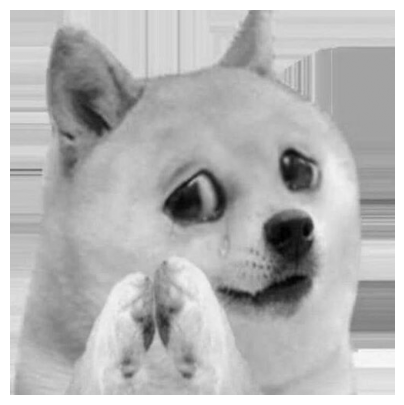

Image shape:  (500, 500)


In [53]:
# Import an image taken by you, make sure it's dimensions does not exceed (512, 512). Downsample if necessary.

image = rgb2gray(img_as_float(imread("/content/rsz_received_711020563367480.jpg")))
plot_image(image)
 # TO-BE-COMPLETED

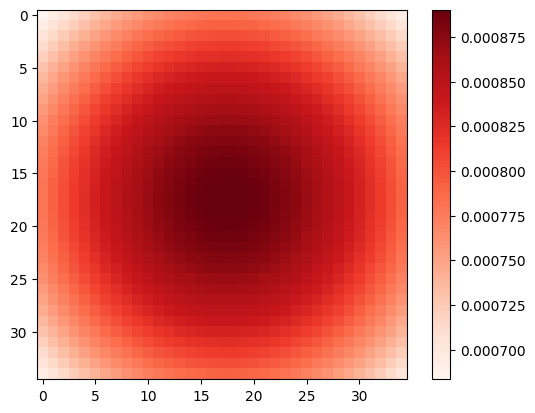

Kernel shape:  (35, 35)


In [54]:
# Define a gaussian kernel of size (35, 35)
kernel = gaussian_kernel(width=35, size=35)
plot_kernel(kernel)
# TO-BE-COMPLETED

Time elapsed (direct): 4.901250554000001 seconds


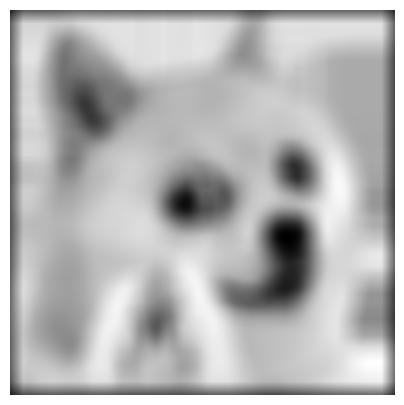

Image shape:  (500, 500)


In [55]:
# Determine the time to filter the image with the kernel using "direct" method
start_time = time.process_time()
filtered_image_direct = signal.correlate(image, kernel, mode='same', method='direct')
print("Time elapsed (direct):", time.process_time() - start_time, "seconds")
plot_image(filtered_image_direct)
# TO-BE-COMPLETED


Time elapsed (fft): 0.02369271399999917 seconds


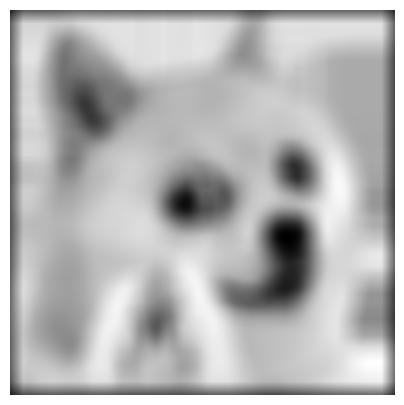

Image shape:  (500, 500)


In [56]:
# Determine the time to filter the image with the kernel using "fft" method

start_time = time.process_time()
filtered_image_fft = signal.correlate(image, kernel, mode='same', method='fft')
print("Time elapsed (fft):", time.process_time() - start_time, "seconds")
plot_image(filtered_image_fft)
# TO-BE-COMPLETED


### **Answer to Task 1** <br>

### Write your answer here. Comment on the results.

Result (answer): Time elapsed (direct): 4.901250554000001 seconds

Time elapsed (fft): 0.02369271399999917 seconds

Comment (answer): Direct method took longer cause it performs spatial correlation pixel-by-pixel and is computationally expensive, especially with a large kernel like 35×35. Where in FFT  it transforms the image and kernel into the frequency domain, performs multiplication, and then converts it back which is much faster for large kernel sizes.

(From here onwards, please use ```method="auto"``` while using any signal function.)

## **Task 2: Correlation Vs. Convolution** <br>
### Comparing the correlation and convolution operation for different kernels<br>


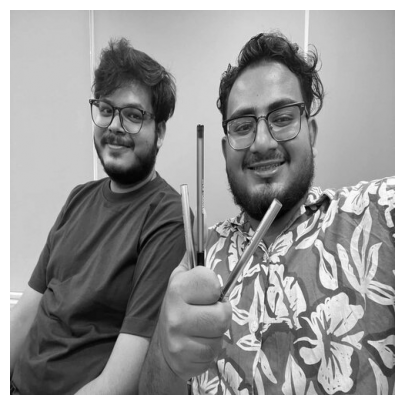

Image shape:  (500, 500)


In [57]:
# Import an image taken by you, make sure it's dimensions does not exceed (512, 512). Downsample if necessary.
image = rgb2gray(img_as_float(imread("/content/rsz_1ca1a59f9-2307-4ce5-b836-259b1e3ae76e.jpg")))
plot_image(image)
# TO-BE-COMPLETED

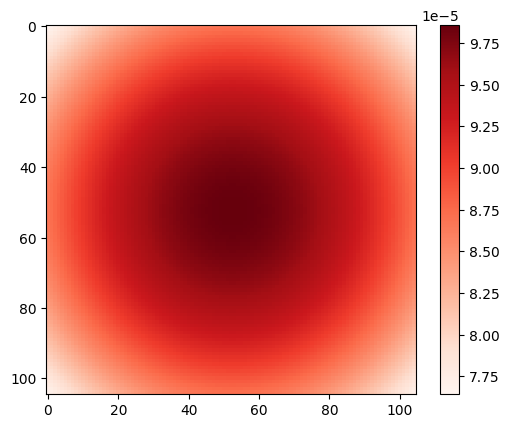

Kernel shape:  (105, 105)


In [58]:
# Define any symmetric kernel of size (105, 105)

kernel_symmetric = gaussian_kernel(width=105, size=105)
plot_kernel(kernel_symmetric)
# TO-BE-COMPLETED

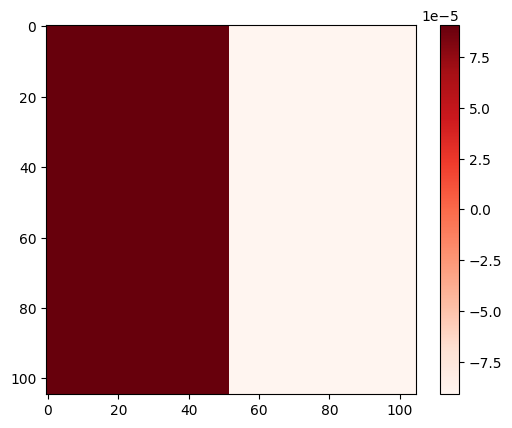

Kernel shape:  (105, 105)


In [59]:
# Define any asymmetric kernel of size (105, 105)
kernel_asymmetric = np.zeros((105, 105))
kernel_asymmetric[:,:52] = 1
kernel_asymmetric[:,52:] = -1
kernel_asymmetric = kernel_asymmetric / np.sum(np.abs(kernel_asymmetric))
plot_kernel(kernel_asymmetric)
 # TO-BE-COMPLETED

In [60]:
# Filter the image with the symmetric kernel using the correlation function
filtered_image_symmetric = signal.correlate(image, kernel_symmetric, mode='same', method='auto')
filtered_image_asymmetric = signal.correlate(image, kernel_asymmetric, mode='same', method='auto')
# TO-BE-COMPLETED
# TO-BE-COMPLETED

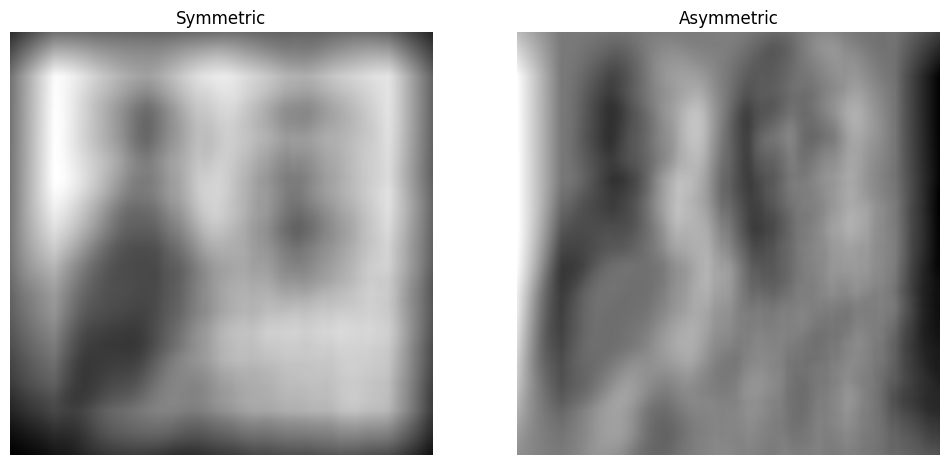

In [63]:
# Display the images side by side (with proper labeling, which is which)


fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(filtered_image_symmetric, cmap="gray")
ax1.set_title("Symmetric")
ax1.axis("off")

ax2 = fig.add_subplot(1,2,2)
ax2.imshow(filtered_image_asymmetric, cmap="gray")
ax2.set_title("Asymmetric")
ax2.axis("off")

plt.show()


### **Answer to Task 2.1** <br>

### Write your answer here. Compare the outputs.

Answer: The symmetric one smoothed out features evenly, while the asymmetric one extracted directional changes in brightness.

symmetric kernel blurred the image uniformly and preserved symmetry across all directions. The result looked like a smooth low-pass filtered version of the image. BUT asymmetric kernel highlighted directional differences especially horizontal contrasts. Because I used left half +1, right half -1. It introduced a strong edge like effect that emphasized brightness contrast to the vertical midlines in the image.

Now, to *convolve* an ```image``` with a ```kernel``` all we need to do is call the ```signal.convolve``` function from the ```scipy``` library.

```
filtered_image = signal.convolve(image, kernel, mode='same', method='auto')```

The parameters work the same way as the ```signal.correlate```function.

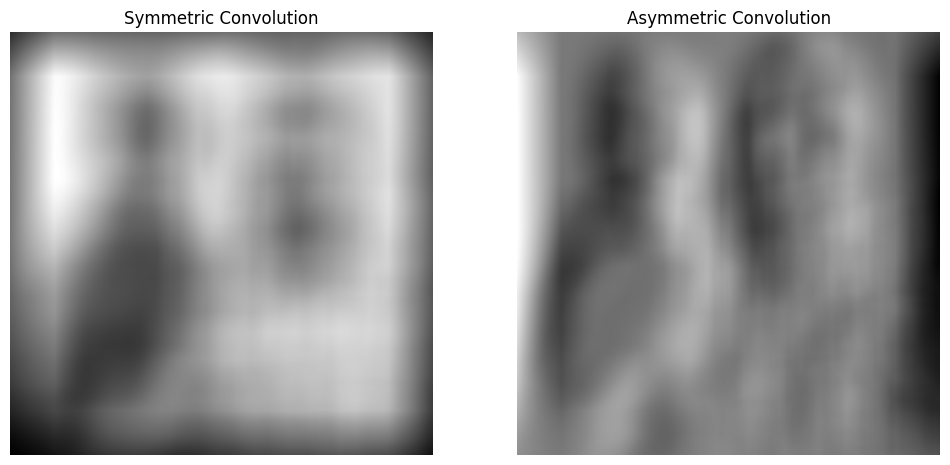

In [62]:
# Filter the image with the asymmetric kernel using the convolution function


filtered_image_symmetric = signal.convolve(image, kernel_symmetric, mode='same', method='auto')
filtered_image_asymmetric = signal.convolve(image, kernel_asymmetric, mode='same', method='auto')

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(filtered_image_symmetric, cmap="gray")
ax1.set_title("Symmetric Convolution")
ax1.axis("off")

ax2 = fig.add_subplot(1,2,2)
ax2.imshow(filtered_image_asymmetric, cmap="gray")
ax2.set_title("Asymmetric Convolution")
ax2.axis("off")

plt.show()



### **Answer to Task 2.2** <br>

### Write your answer here. Compare the outputs.
Answer:convolution with symmetric kernel gave an almost identical result to correlation because symmetric kernels remain the same when flipped. BUT for asymmetric kernel convolution produced a different effect than correlation. This is because convolution flips the kernel before applying, while correlation does not do that.


## **Task 3: Edge Pair Detector** <br>
### Try to come up with two 3 x 3 filter kernels which are able to detect ***only the parallel pair of edges*** in the following image<br>

![](https://drive.google.com/uc?export=view&id=1a1CXbuC8A2FbyFvZovJMXERUijpatecU)

[The image can be downloaded from here: https://drive.google.com/file/d/1a1CXbuC8A2FbyFvZovJMXERUijpatecU/view?usp=sharing]

*Hint: No mathematical derivation is necessary. Just try devising the kernels using the same intuitions used behind the horizontal and vertical edge detector kernels. Coming up with a filter kernel means to determine the 9 filter coefficients of the 3x3 filer kernel.*

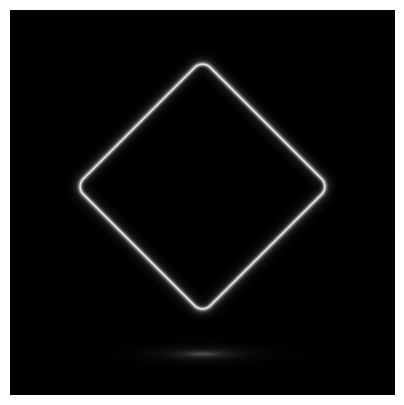

Image shape:  (626, 626)


In [64]:
# Download the image from the drive link above and upload it to your current working directory in colab. Then load the image
image = rgb2gray(img_as_float(imread("/content/diamond2.jpg")))
plot_image(image)
 # TO-BE-COMPLETED

In [65]:
# define the 2 custom kernels by replacing the "?"s with your values and uncomment the next few lines of code in this cell
kernel_1 = np.array([[1, 0, -1], # TO-BE-COMPLETED
                      [1, 0, -1], # TO-BE-COMPLETED
                    [1, 0, -1]]) # TO-BE-COMPLETED

kernel_2 = np.array([[1, 1, 1], # TO-BE-COMPLETED
                     [0, 0,0 ], # TO-BE-COMPLETED
                     [-1, -1, -1]]) # TO-BE-COMPLETED

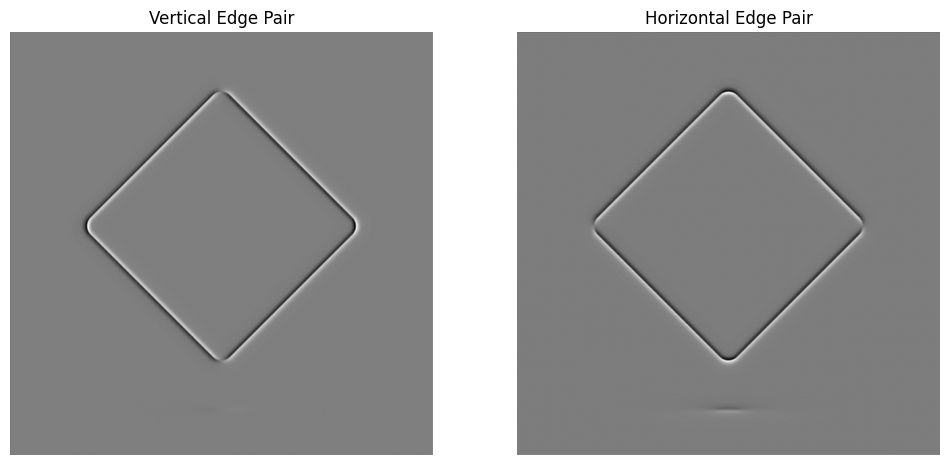

In [66]:
# detect the 2 parallel pair of edges and plot them side by side in a 1x2 grid subplot

# detect the first pair using image filtering with kernel_1

first_pair_detected = signal.correlate(image, kernel_1, mode='same', method='auto') # TO-BE-COMPLETED

# detect the second pair using image filtering with kernel_2

second_pair_detected = signal.correlate(image, kernel_2, mode='same', method='auto') # TO-BE-COMPLETED

# plot the two filtered images side by side
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(first_pair_detected, cmap="gray")
ax1.set_title("Vertical Edge Pair")
ax1.axis("off")

ax2 = fig.add_subplot(1,2,2)
ax2.imshow(second_pair_detected, cmap="gray")
ax2.set_title("Horizontal Edge Pair")
ax2.axis("off")

plt.show()
# TO-BE-COMPLETED
# TO-BE-COMPLETED
# TO-BE-COMPLETED
# TO-BE-COMPLETED
# TO-BE-COMPLETED
# TO-BE-COMPLETED
# TO-BE-COMPLETED


### **Answer to Task 3** <br>

### Write your answer here. Which filters you came up with and why? How did you choose the coefficients? Are your kernels unique or there can be other kernels which can accomplish the same task?


Answer:These are based on classic Sobel like filters adapted for pair detection. they havve the visible differences between two opposing sides top/bottom or left/right. The values create strong gradients to the respective axis, highlighting edge pairs.

No, these are not the only solutions. Other kernels like diagonals,custom gradients can detect similar structures. These filters are chosen for simplicity and effectiveness, but there are multiple ways to achieve similar results depending on orientation.

## **The END**